# Sanity check: stage 1a dataset generation

Generates a small (240-sample) dataset with `simulator.generate_dataset_fast` and checks that it looks right before kicking off the full 10^5-sample run:

- histograms of the four free parameters (`lam`, `beta`, `inc`, `psi`) against their priors
- `lam`/`beta` plotted on the sky sphere, to check the sky coverage looks uniform
- the `bumps` envelope for one sample, to eyeball that the modulation/nulls look sane

See `SUMMARY.md` and `CLAUDE.md` for project context.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import simulator as sim
import priors

N_SAMPLES = 240
OUTPUT_PATH = "sanity_check_dataset.npz"

No CuPy


## Generate the dataset

240 samples, using the same `generate_dataset_fast` path the real 10^5-sample run will use (6-worker CPU generation per round, decoupled MPS post-processing). Should take on the order of a couple of minutes.

In [ ]:
bumps, free_params = sim.generate_dataset_fast(N_SAMPLES, OUTPUT_PATH)
print(f"bumps shape: {bumps.shape}")
for name, values in free_params.items():
    print(f"{name}: shape={values.shape} min={values.min():.4f} max={values.max():.4f}")

round 1/10: 24/240 samples (13s elapsed, 1.814 samples/s, ETA 0.03h)


round 2/10: 48/240 samples (25s elapsed, 1.911 samples/s, ETA 0.03h)


round 3/10: 72/240 samples (37s elapsed, 1.931 samples/s, ETA 0.02h)


round 4/10: 96/240 samples (49s elapsed, 1.962 samples/s, ETA 0.02h)


round 5/10: 120/240 samples (60s elapsed, 1.992 samples/s, ETA 0.02h)


...

round 8/10: 192/240 samples (94s elapsed, 2.036 samples/s, ETA 0.01h)


round 9/10: 216/240 samples (106s elapsed, 2.044 samples/s, ETA 0.00h)


round 10/10: 240/240 samples (119s elapsed, 2.014 samples/s, ETA 0.00h)


No CuPy
No CuPy
No CuPy
No CuPy
No CuPy
No CuPy


bumps shape: (240, 3, 731)
lam: shape=(240,) min=0.0028 max=6.2558
beta: shape=(240,) min=-1.3628 max=1.3941
inc: shape=(240,) min=0.1683 max=3.1155
psi: shape=(240,) min=0.0012 max=3.1412


## Histograms of the sampled parameters

One panel per active parameter (whatever `config.yaml`'s `active_params` currently is -- not hardcoded to `lam`/`beta`/`inc`/`psi`, so this stays correct if that list changes later), with the physical range marked.

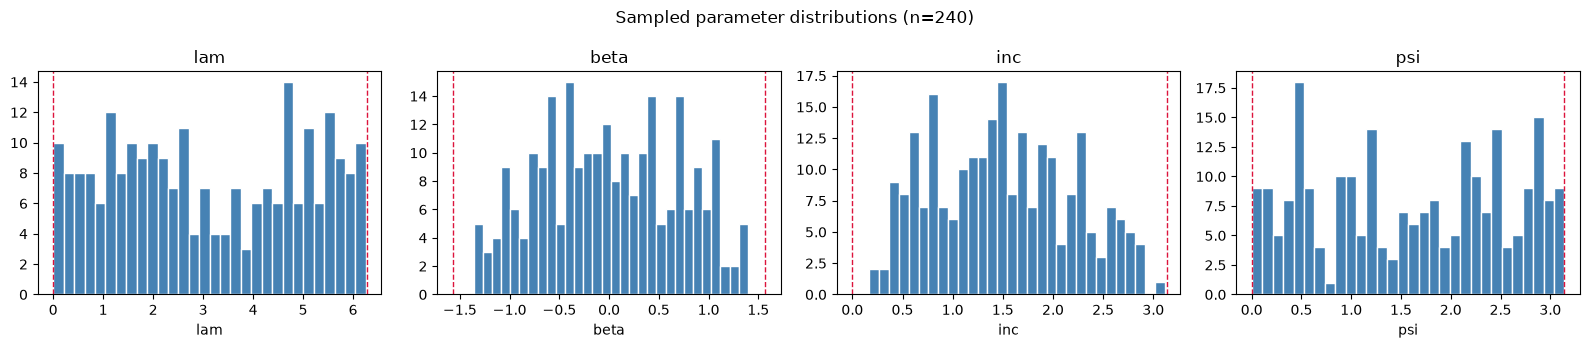

In [3]:
# Known physical domains for the angle parameters, for reference lines on the
# histograms below (config.yaml's priors are given in transformed space --
# e.g. sin(beta), cos(inc) -- not these physical bounds directly).
PHYSICAL_BOUNDS = {
    "lam": (0.0, 2 * np.pi),
    "beta": (-np.pi / 2, np.pi / 2),
    "inc": (0.0, np.pi),
    "psi": (0.0, np.pi),
}

param_names = list(free_params.keys())
fig, axes = plt.subplots(1, len(param_names), figsize=(4 * len(param_names), 3.5))
if len(param_names) == 1:
    axes = [axes]

for ax, name in zip(axes, param_names):
    ax.hist(free_params[name], bins=30, color="steelblue", edgecolor="white")
    if name in PHYSICAL_BOUNDS:
        low, high = PHYSICAL_BOUNDS[name]
        ax.axvline(low, color="crimson", linestyle="--", linewidth=1)
        ax.axvline(high, color="crimson", linestyle="--", linewidth=1)
    ax.set_title(name)
    ax.set_xlabel(name)

fig.suptitle(f"Sampled parameter distributions (n={N_SAMPLES})")
fig.tight_layout()
plt.show()

(array([ 7., 10.,  6.,  7.,  5., 12.,  4.,  4.,  6.,  7.,  9.,  6.,  6.,
        10.,  4., 10., 11., 11.,  8.,  6.,  9., 10.,  4.,  5.,  6., 15.,
         7., 15., 15.,  5.]),
 array([-0.99965864, -0.93347441, -0.86729018, -0.80110595, -0.73492171,
        -0.66873748, -0.60255325, -0.53636902, -0.47018479, -0.40400056,
        -0.33781633, -0.2716321 , -0.20544786, -0.13926363, -0.0730794 ,
        -0.00689517,  0.05928906,  0.12547329,  0.19165752,  0.25784176,
         0.32402599,  0.39021022,  0.45639445,  0.52257868,  0.58876291,
         0.65494714,  0.72113138,  0.78731561,  0.85349984,  0.91968407,
         0.9858683 ]),
 <BarContainer object of 30 artists>)

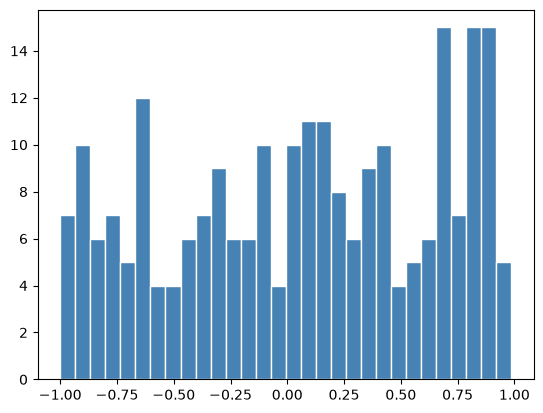

In [4]:
plt.hist(np.cos(free_params["inc"]), bins=30, color="steelblue", edgecolor="white")

## Sky position (`lam`, `beta`) on the sphere

`lam` is ecliptic longitude, `beta` is ecliptic latitude. Converting to Cartesian coordinates on the unit sphere -- the points should look uniformly scattered over the whole sphere (this is exactly what the `sin(beta)`/`cos(inc)`-space priors were for).

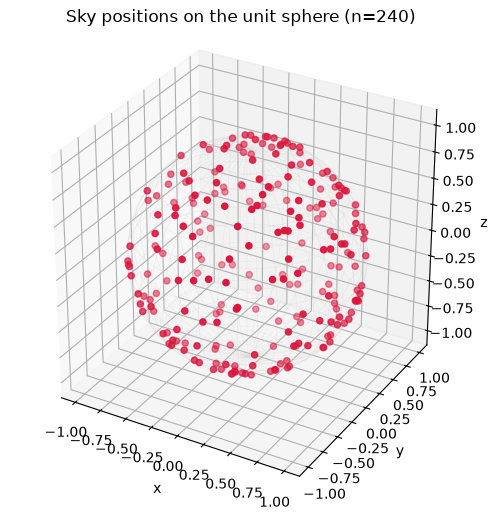

In [5]:
lam = free_params["lam"]
beta = free_params["beta"]

x = np.cos(beta) * np.cos(lam)
y = np.cos(beta) * np.sin(lam)
z = np.sin(beta)

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(projection="3d")

# faint reference sphere
u = np.linspace(0, 2 * np.pi, 40)
v = np.linspace(0, np.pi, 20)
ax.plot_wireframe(
    np.outer(np.cos(u), np.sin(v)),
    np.outer(np.sin(u), np.sin(v)),
    np.outer(np.ones_like(u), np.cos(v)),
    color="lightgray", linewidth=0.3, alpha=0.5,
)

ax.scatter(x, y, z, color="crimson", s=20, depthshade=True)
ax.set_box_aspect([1, 1, 1])
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title(f"Sky positions on the unit sphere (n={N_SAMPLES})")
plt.show()

## Sky coverage check with more samples (no waveform generation)

240 samples is too few to tell whether `lam`/`beta` are actually uniform over
the sphere. This draws 10000 `lam`/`beta` samples directly from
`priors.sample_free_parameters` -- skipping `simulator.generate_dataset_fast`
entirely, since sky coverage doesn't depend on the waveform -- and re-plots
the histograms and sphere scatter at that higher sample count.

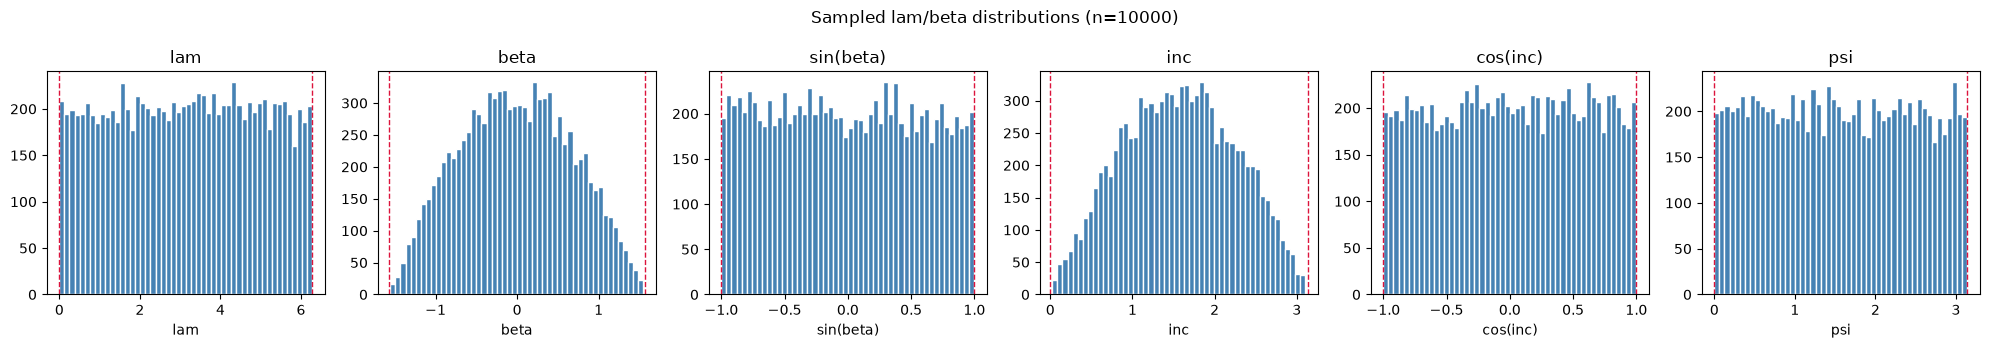

In [6]:
PHYSICAL_BOUNDS = {
    "lam": (0.0, 2 * np.pi),
    "beta": (-np.pi / 2, np.pi / 2),
    "inc": (0.0, np.pi),
    "psi": (0.0, np.pi),
    "sin(beta)": (-1.0, 1.0),
    "cos(inc)": (-1.0, 1.0),
}

N_SKY_CHECK = 10000
sky_check = priors.sample_free_parameters(N_SKY_CHECK)
lam_check = sky_check["lam"]
beta_check = sky_check["beta"]
sin_beta_check = np.sin(beta_check)
inc_check = sky_check["inc"]
cos_inc_check = np.cos(inc_check)
psi_check = sky_check["psi"]

fig, axes = plt.subplots(1, 6, figsize=(20, 3.5))
for ax, name, values in zip(axes, ["lam", "beta", "sin(beta)", "inc", "cos(inc)", "psi"], [lam_check, beta_check, sin_beta_check, inc_check, cos_inc_check, psi_check]):
    ax.hist(values, bins=50, color="steelblue", edgecolor="white")
    low, high = PHYSICAL_BOUNDS[name]
    ax.axvline(low, color="crimson", linestyle="--", linewidth=1)
    ax.axvline(high, color="crimson", linestyle="--", linewidth=1)
    ax.set_title(name)
    ax.set_xlabel(name)

fig.suptitle(f"Sampled lam/beta distributions (n={N_SKY_CHECK})")
fig.tight_layout()
plt.show()

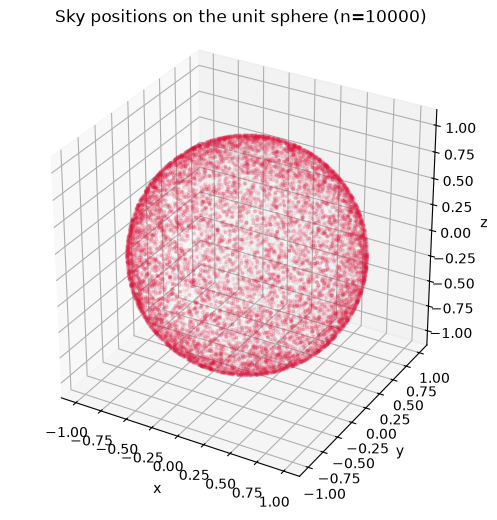

In [7]:
x_check = np.cos(beta_check) * np.cos(lam_check)
y_check = np.cos(beta_check) * np.sin(lam_check)
z_check = np.sin(beta_check)

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(projection="3d")

# faint reference sphere
u = np.linspace(0, 2 * np.pi, 40)
v = np.linspace(0, np.pi, 20)
ax.plot_wireframe(
    np.outer(np.cos(u), np.sin(v)),
    np.outer(np.sin(u), np.sin(v)),
    np.outer(np.ones_like(u), np.cos(v)),
    color="lightgray", linewidth=0.3, alpha=0.5,
)

ax.scatter(x_check, y_check, z_check, color="crimson", s=4, alpha=0.4, depthshade=True)
ax.set_box_aspect([1, 1, 1])
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title(f"Sky positions on the unit sphere (n={N_SKY_CHECK})")
plt.show()

## `bumps` envelope for one sample

The per-time-bin max STFT magnitude for each of the 3 TDI channels (A, E, T), for a single sample -- this is the actual per-sample feature the network will train on. Plotted in log scale since the nulls span several orders of magnitude.

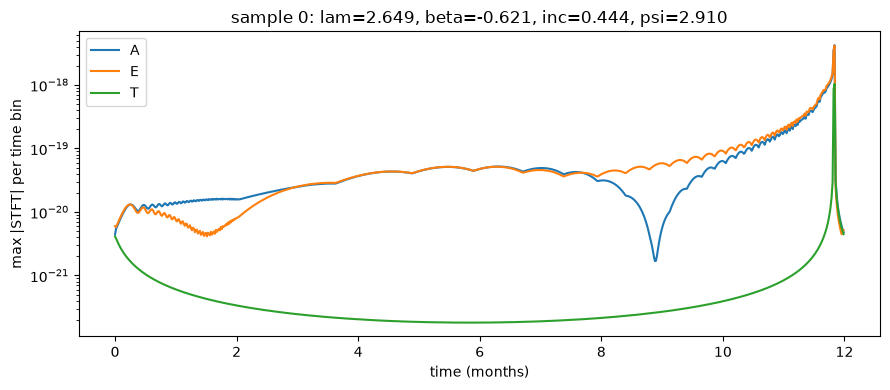

In [8]:
SAMPLE_INDEX = 0
MONTH_SI = 30.45428241 * 24 * 3600

n_time_bins = bumps.shape[-1]
t_months = np.arange(n_time_bins) * sim.HOP_LENGTH * sim.dt / MONTH_SI

fig, ax = plt.subplots(figsize=(9, 4))
for channel_i, label in enumerate(["A", "E", "T"]):
    ax.plot(t_months, bumps[SAMPLE_INDEX, channel_i], label=label)

ax.set_yscale("log")
ax.set_xlabel("time (months)")
ax.set_ylabel("max |STFT| per time bin")
params_str = ", ".join(f"{k}={v[SAMPLE_INDEX]:.3f}" for k, v in free_params.items())
ax.set_title(f"sample {SAMPLE_INDEX}: {params_str}")
ax.legend()
fig.tight_layout()
plt.show()